# Data Analysis Graph

This notebook implements a LangGraph workflow for data analysis using AI agents.

## Setup and Configuration

In [81]:
# Import required libraries
import sys
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent.parent
sys.path.insert(0, str(project_root))

# Import settings
from src.config import settings

print(f"Application: {settings.app_name}")
print(f"Version: {settings.app_version}")
print(f"Default LLM Model: {settings.default_llm_model}")
print(f"Temperature: {settings.default_llm_temperature}")


Application: Data Agent LangGraph
Version: 0.1.0
Default LLM Model: gpt-4o
Temperature: 0.7


## Import Dependencies

In [82]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
import pandas as pd
import numpy as np
from typing import Any, Optional, List

## State definition

In [83]:
class UploadedAtPayload(TypedDict):
    from_date: str
    to_date: str

class FieldsPayload(TypedDict):
    name: str
    value: str
    
class DocFieldsPayload(TypedDict):
    doctype: str
    fields: List[FieldsPayload]
    
class SearchPayload(TypedDict):
    uploaded_at: Optional[UploadedAtPayload]
    queues: Optional[List[str]]
    others: DocFieldsPayload

class OverallState(TypedDict):
    messages: Annotated[list, add_messages]
    intent: Optional[str]
    search_attributes: Optional[list[str]]
    search_payload: Optional[dict[str,SearchPayload]]

## Init LLM

In [84]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model=settings.default_llm_model, 
    temperature=settings.default_llm_temperature,
    api_key=settings.openai_api_key
)

## Intent classification node

In [85]:
from typing import Literal
from pydantic import BaseModel, Field

class IntentClassificationOutput(BaseModel):
    intent: Literal["search", "document_accuracy", "document_counter", "document_processing_time", "others"] = Field(
        ..., 
        description="The user's intent based on the conversation."
    )    
    reasoning: str = Field(..., description="The reasoning behind the intent classification.")


intent_classification_instructions="""

You are an intent classification assistant. Your task is to analyze user queries and classify them into one of the following intents based on the provided conversation context.

1. search - User wants to search for documents with specific criteria
2. document_accuracy - User wants to know about document extraction accuracy
3. document_counter - User wants to know document counts or statistics
4. document_processing_time - User wants to know about processing time or duration
5. others - User query doesn't match any of the above intents

Examples:

User Query: help me search all documents from queue nam containing xyz, uploaded from xx to yy, the doc type is Invoice
Intent: search
Reasoning: User is requesting to search for documents with specific filters including queue name, content, upload date range, and document type.

User Query: i wanna to know the accuracy of document extraction
Intent: document_accuracy
Reasoning: User is explicitly asking about the accuracy metrics of the document extraction process.

User Query: i wanna know the document counter
Intent: document_counter
Reasoning: User is asking for document count statistics.

User Query: i wanna know the processing time
Intent: document_processing_time
Reasoning: User wants information about how long document processing takes.

User Query: how are you
Intent: others
Reasoning: Hi I am good, how are you? I am an AI agent helping you to search documents, and learn about document accuracy, document counter, document processing time. Please specify one of these if you need assistance.

The conversation context is provided below.

"""


def intent_classifier(state: OverallState):
    
    structured_llm = llm.with_structured_output(IntentClassificationOutput)
    
    output = structured_llm.invoke([SystemMessage(content=intent_classification_instructions)] + state["messages"])
    
    print("llm_output: ", output)
    
    return {"intent": output.intent,"messages":[AIMessage(content=output.reasoning)]}


## Request user input for edge cases:

In [86]:
def user_input_clarity(state:OverallState):
    pass

## Conditional routing for intent

In [87]:
def routing_intent(state: OverallState):
    if state['intent'] in ["document_accuracy", "document_counter", "document_processing_time"]:
        return END
    
    if state['intent'] == 'others':
        # human in the loop ask user to input again
        return "user_input_clarity"
    
    return "extract_search_attributes_from_query"

## Extract search attrbutes for search query

In [88]:
search_attributes_extraction_prompt = """
You are a search attributes analyzer for a document management system.

Your task is to identify which search attributes the user wants to use from their query.

ALLOWED SEARCH ATTRIBUTES (you can ONLY return these):
1. "document_model" - when user wants to search by document type, document model, or document category (e.g., invoice, receipt, contract)
2. "queue" - when user wants to search by queue name (e.g., invoice queue, HR queue, claims queue, louis_test queue)
3. "date" - when user wants to search by date, date range, or time period (e.g., yesterday, last week, last month, January 15th)

IMPORTANT RULES:
- You MUST only return attributes from the allowed list: ["document_type", "queue", "date"]
- Return ALL applicable attributes that the user mentioned
- If user mentions status tabs (received, completed, exported, rejected), these are NOT valid attributes - ignore them
- If user mentions "uploaded by person", this is NOT a valid attribute - ignore it
- Return an empty list if the query is not a search query
- Be careful to distinguish between queue names and document types

Examples:

Query: "Show me documents in the invoice queue"
Attributes: ["queue"]
Reasoning: User wants to filter by queue name "invoice"

Query: "Find documents from last week"
Attributes: ["date"]
Reasoning: User wants to filter by time period "last week"

Query: "Search for documents in louis_test queue from yesterday"
Attributes: ["queue", "date"]
Reasoning: User wants to filter by queue name "louis_test" and date "yesterday"

Query: "Show me documents in the claims queue"
Attributes: ["queue"]
Reasoning: User wants to filter by queue name "claims"

Query: "Find documents dated January 15th"
Attributes: ["date"]
Reasoning: User wants to filter by specific date "January 15th"

Query: "Show me all documents in invoice model from last month"
Attributes: ["document_type", "date"]
Reasoning: User wants to filter by document type "invoice" and time period "last month"

Query: "Documents in HR queue"
Attributes: ["queue"]
Reasoning: User wants to filter by queue name "HR"

Query: "Show me completed documents" (completed is status - NOT allowed)
Attributes: []
Reasoning: "Completed" is a status, not a valid search attribute, so no attributes extracted

Query: "Documents uploaded by John" (uploaded by is NOT allowed)
Attributes: []
Reasoning: "Uploaded by" is not a valid search attribute, so no attributes extracted

Query: "Show me invoice documents from yesterday in the processing queue"
Attributes: ["document_type", "date", "queue"]
Reasoning: User wants to filter by document type "invoice", date "yesterday", and queue "processing"

Query: "Hello"
Attributes: []
Reasoning: This is a greeting, not a search query

Query: "What can you do?"
Attributes: []
Reasoning: This is a help request, not a search query

Query: "Find all invoice type documents"
Attributes: ["document_type"]
Reasoning: User wants to filter by document type "invoice"
"""

# Pydantic model for LLM response
class AttributesExtraction(BaseModel):
    """Classification of user intent"""
    attributes: List[Literal["document_model", "queue", "date"]] = Field(
        description="The attributes that need to be extracted. Must only contain: document model, queue, or date"
    )


# Node 2: Search Node (placeholder)
def extract_search_attributes_from_query(state: OverallState) -> dict:
    """Placeholder search node - empty for now"""
    
    print(f"\n🔎 I am extracting search attibutes from your query: '{state['messages'][-1].content}'")
    
    # Use structured output with Pydantic
    structured_llm = llm.with_structured_output(AttributesExtraction)
    
    messages = [SystemMessage(content=search_attributes_extraction_prompt)] + state['messages']
    
    result: AttributesExtraction = structured_llm.invoke(messages)
    
    print("extracted attributed result: ",result)
    
    if not result.attributes:
        print("There are no valid attributes can be extracted from your query")
    else:
        print(f"Valid extracted attributes: {', '.join(result.attributes)}")
    
    
    return {
        "search_attributes": result.attributes
    }

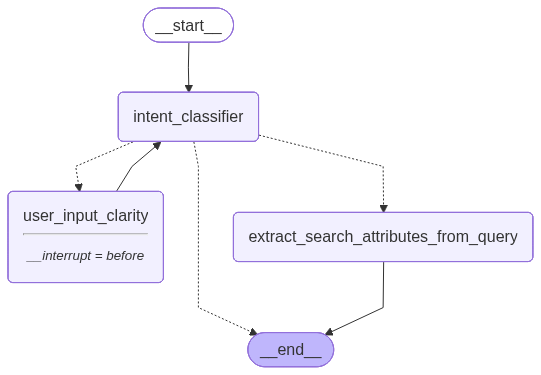

In [89]:
from IPython.display import Image, display


test_builder=StateGraph(OverallState)

test_builder.add_node("intent_classifier",intent_classifier)
test_builder.add_node("user_input_clarity",user_input_clarity)
test_builder.add_node("extract_search_attributes_from_query",extract_search_attributes_from_query)


test_builder.add_edge(START,"intent_classifier")
test_builder.add_conditional_edges("intent_classifier", routing_intent, ["user_input_clarity", "extract_search_attributes_from_query",END])
test_builder.add_edge("user_input_clarity","intent_classifier")
test_builder.add_edge("extract_search_attributes_from_query",END)


# Compile
graph = test_builder.compile(interrupt_before=["user_input_clarity"])

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [92]:
graph.invoke({"messages": [HumanMessage(content="I want to search all documents from queue xyz from 1/11/2025 to now and from invoice model")]})

llm_output:  intent='search' reasoning="The user is asking to search for documents with specific criteria: a queue name 'xyz', a date range from 1/11/2025 to now, and a document type 'invoice model'. This clearly aligns with the search intent as they are specifying filters for a document search."

🔎 I am extracting search attibutes from your query: 'The user is asking to search for documents with specific criteria: a queue name 'xyz', a date range from 1/11/2025 to now, and a document type 'invoice model'. This clearly aligns with the search intent as they are specifying filters for a document search.'
extracted attributed result:  attributes=['document_model', 'queue', 'date']
Valid extracted attributes: document_model, queue, date


{'messages': [HumanMessage(content='I want to search all documents from queue xyz from 1/11/2025 to now and from invoice model', additional_kwargs={}, response_metadata={}, id='41ba7f3f-5157-46cf-aaa1-3e13492da2bc'),
  AIMessage(content="The user is asking to search for documents with specific criteria: a queue name 'xyz', a date range from 1/11/2025 to now, and a document type 'invoice model'. This clearly aligns with the search intent as they are specifying filters for a document search.", additional_kwargs={}, response_metadata={}, id='85ff78ca-0320-4d88-850f-9cfbad8bfc25')],
 'intent': 'search',
 'search_attributes': ['document_model', 'queue', 'date']}